In [1]:
import os
from nilearn.image import mean_img

bids_path = '/DATAPOOL/VPMB/BIDS-VPMB-SPE'
fmriprep_path = '/DATAPOOL/VPMB/BIDS-VPMB-SPE/derivatives/fmriprep23/fmriprep/'
fmri_img = os.path.join(fmriprep_path,
                        'sub-01/func/sub-01_task-loc_acq-1000_run-1_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.nii.gz')


In [2]:
mean_img = mean_img(fmri_img)

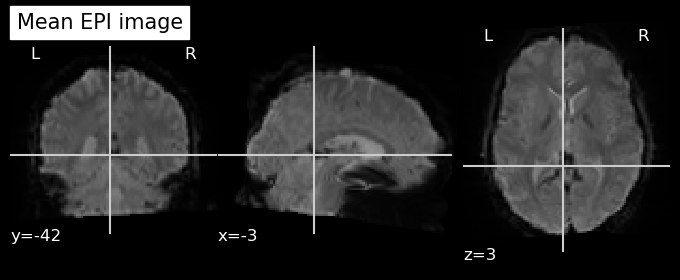

In [3]:
from nilearn.plotting import plot_anat, plot_img, plot_stat_map

plot_anat(mean_img, title='Mean EPI image')

In [4]:
import pandas as pd

events = pd.read_table(os.path.join(bids_path,
                                    'sub-01/func/sub-01_task-loc_acq-1000_run-1_events.tsv'))
events

,onset,duration,trial_type
0,0,6,Discard
1,6,6,Fixation
2,12,6,StaticPlaid
3,18,6,MovingPlaid
4,24,6,Fixation
5,30,6,StaticPlaid
6,36,6,MovingPlaid
7,42,6,Fixation
8,48,6,StaticPlaid
9,54,6,MovingPlaid


In [77]:
# fetch confounds
all_confounds = pd.read_table(os.path.join(fmriprep_path,
                                        'sub-01/func/sub-01_task-loc_acq-1000_run-1_desc-confounds_timeseries.tsv'))

# select the columns that we want: csf, white_matter, trans_*, rot_*
confounds = all_confounds[['csf','white_matter','trans_x','trans_y','trans_z','rot_x','rot_y','rot_z']]

# zscore the confounds
# confounds = confounds.apply(lambda x: (x - x.mean()) / x.std(), axis=0)
confounds


,csf,white_matter,trans_x,trans_y,trans_z,rot_x,rot_y,rot_z
0,9.550977,2.491338,3.151032,-0.153691,-0.801707,-0.113638,-2.517414,-3.028345
1,5.069126,1.476202,2.169359,-0.906210,-1.499471,0.677129,-2.260430,-3.123566
2,2.738752,1.501544,1.577575,-1.405184,-2.177916,1.068268,-2.126762,-3.136959
3,2.721642,1.867383,2.858832,1.329227,0.268686,-0.247277,-2.214157,-2.962545
4,1.485819,1.437568,2.132084,0.400851,-0.095264,0.120568,-2.064275,-2.716216
...,...,...,...,...,...,...,...,...
169,-0.163420,-0.926343,-0.082558,1.523785,-0.395211,0.785039,1.096138,0.850124
170,-0.978481,-0.625920,-0.514658,-0.947741,-1.946012,1.978297,1.325594,0.897985
171,-0.470725,0.707798,-0.192487,1.125446,-0.770386,0.993104,1.197833,0.922158
172,-0.390455,0.281479,-0.398094,1.881260,-0.390663,0.375579,1.222904,0.850124


In [78]:
from nilearn.glm.first_level import FirstLevelModel

fmri_glm = FirstLevelModel(
    t_r=1,
    noise_model="ar1",
    standardize=False,
    hrf_model="spm",
    drift_model="cosine",
    high_pass=0.03,
    smoothing_fwhm=4,
    n_jobs=12
)

fmri_glm = fmri_glm.fit(fmri_img, events, confounds)

design_matrix = fmri_glm.design_matrices_[0]

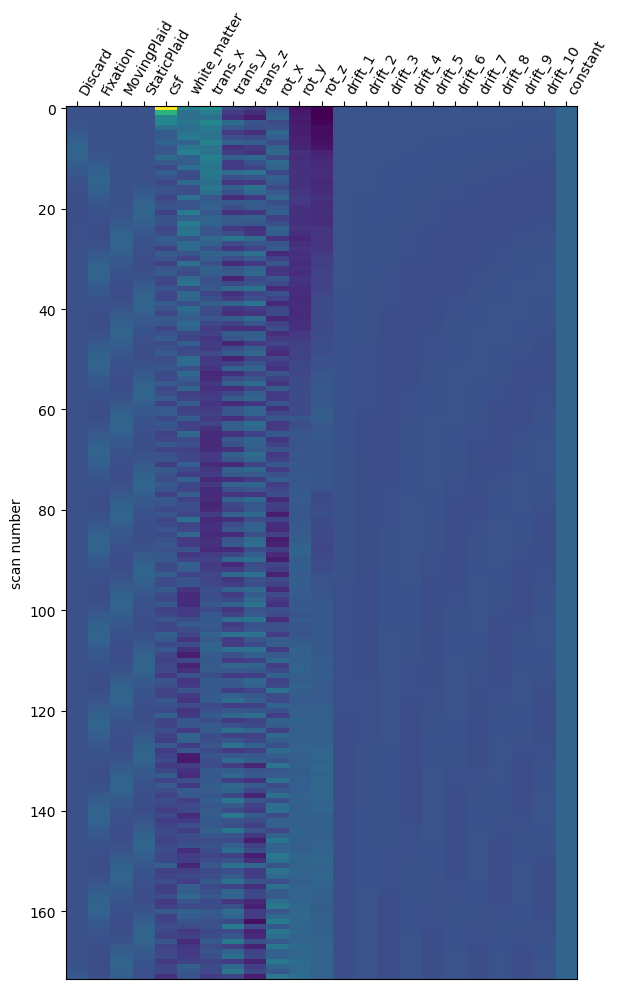

In [79]:
import matplotlib.pyplot as plt
from nilearn.plotting import plot_design_matrix

plot_design_matrix(design_matrix,rescale=False)

plt.show()

<Axes: label='conditions'>

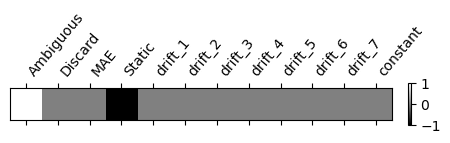

In [14]:
# import numpy as np

# conditions = {"Ambiguous": np.zeros(12), "Static": np.zeros(12)}
# conditions["Ambiguous"][0] = 1
# conditions["Static"][3] = 1

# ambiguous_minus_static = conditions["Ambiguous"] - conditions["Static"]

# from nilearn.plotting import plot_contrast_matrix

# plot_contrast_matrix(ambiguous_minus_static, design_matrix=design_matrix, colorbar=True)

<Axes: label='conditions'>

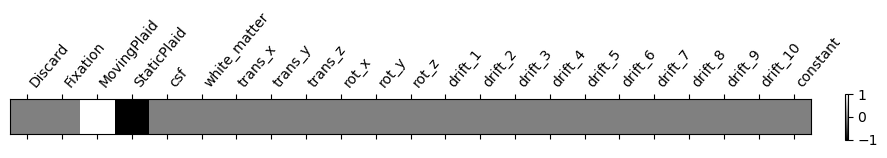

In [64]:
import numpy as np

# number of predictors
n_predictors = design_matrix.shape[1]

conditions = {"MovingPlaid": np.zeros(n_predictors), "StaticPlaid": np.zeros(n_predictors)}
conditions["MovingPlaid"][2] = 1
conditions["StaticPlaid"][3] = 1

moving_minus_static = conditions["MovingPlaid"] - conditions["StaticPlaid"]

from nilearn.plotting import plot_contrast_matrix

plot_contrast_matrix(moving_minus_static, design_matrix=design_matrix, colorbar=True)

In [80]:
z_map = fmri_glm.compute_contrast(moving_minus_static, output_type="z_score")

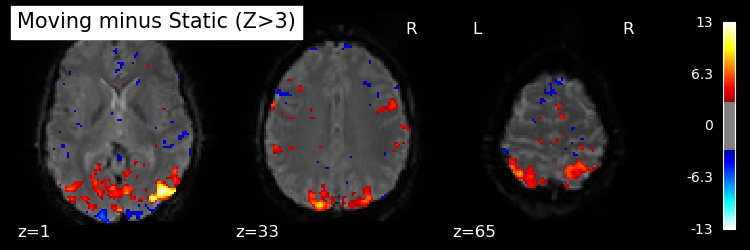

In [66]:
plot_stat_map(
    z_map,
    bg_img=mean_img,
    threshold=3.0,
    display_mode="z",
    cut_coords=3,
    black_bg=True,
    title="Moving minus Static (Z>3)",
)
plt.show()

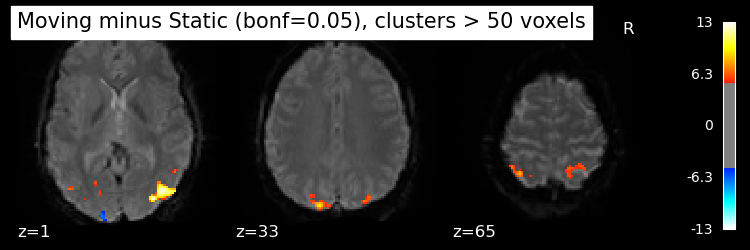

In [81]:
from nilearn.glm import threshold_stats_img

clean_map, threshold = threshold_stats_img(
    z_map, alpha=0.05, height_control="bonferroni", cluster_threshold=50
)
plot_stat_map(
    clean_map,
    bg_img=mean_img,
    threshold=threshold,
    display_mode="z",
    cut_coords=3,
    black_bg=True,
    title="Moving minus Static (bonf=0.05), clusters > 50 voxels",
)
plt.show()

/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/numpy/core/fromnumeric.py:784: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



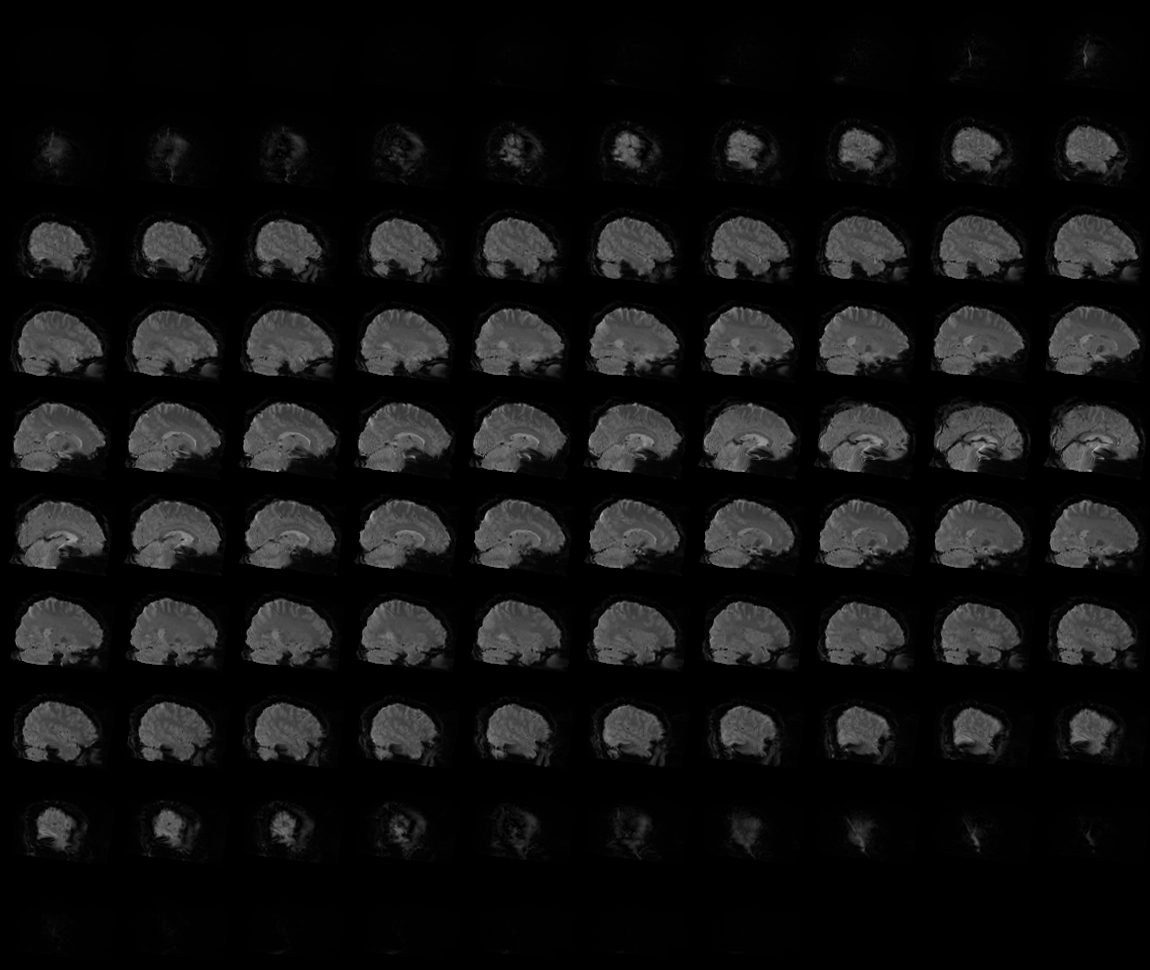
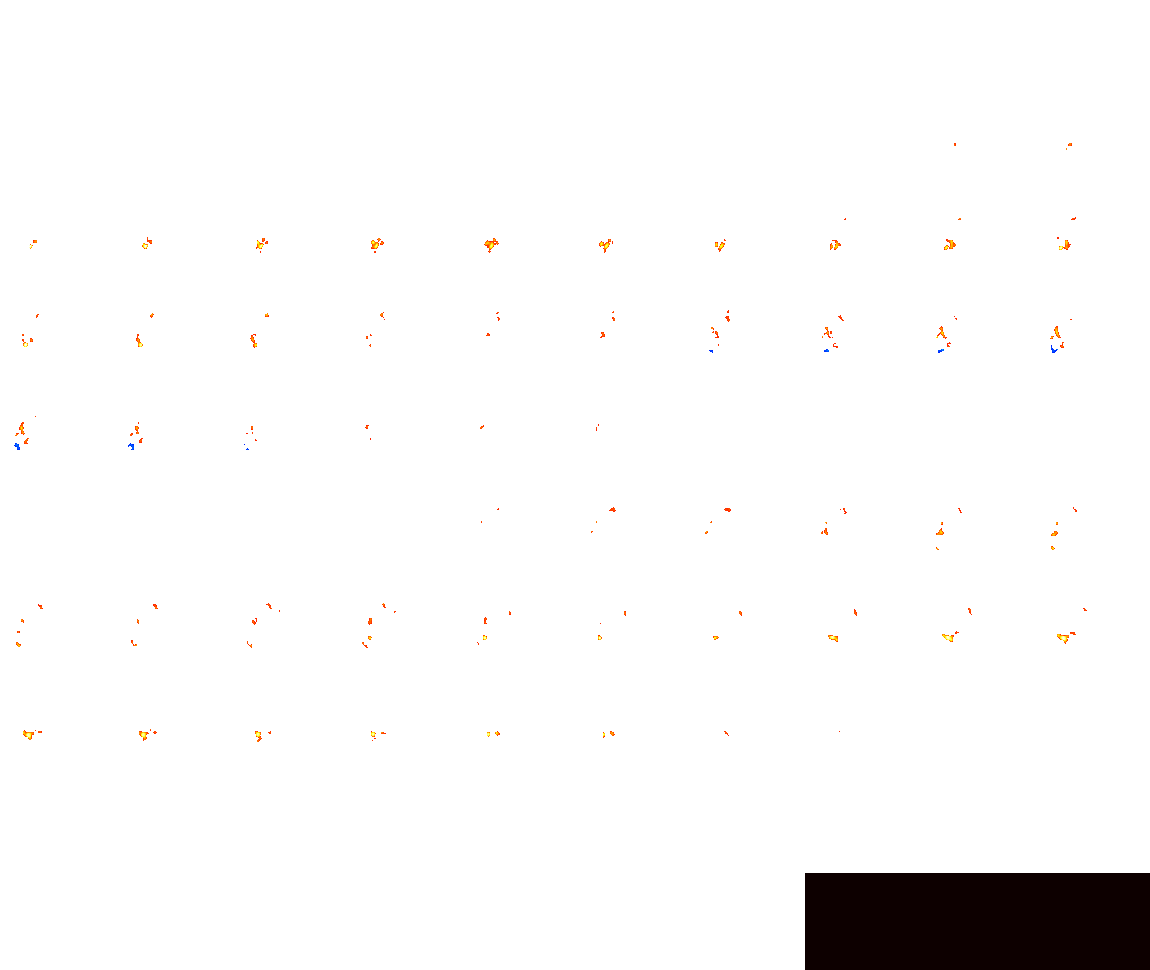

In [68]:
from nilearn.plotting import view_img

view_img(clean_map,
         bg_img=mean_img,
         threshold=threshold
        )

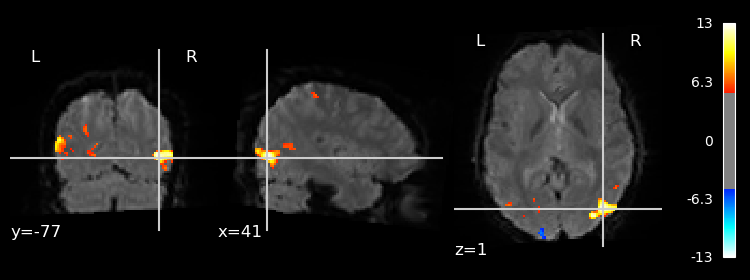

In [82]:
plot_stat_map(
    clean_map,
    bg_img=mean_img,
    threshold=threshold,
    display_mode="ortho",
    cut_coords=(41,-77,1),
    black_bg=True
)

In [83]:
from nilearn.reporting import get_clusters_table

table = get_clusters_table(
    z_map, stat_threshold=threshold, cluster_threshold=50
)
table

,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3)
0,1,-54.5,-72.5,9.5,12.567423,8472
1,1a,-36.5,-82.5,7.5,12.491145,
2,1b,-52.5,-78.5,17.5,10.539460,
3,1c,-20.5,-100.5,21.5,9.235915,
4,2,41.5,-76.5,1.5,12.340928,3464
5,2a,33.5,-84.5,3.5,11.878575,
6,2b,49.5,-76.5,3.5,11.489424,
7,2c,39.5,-86.5,7.5,9.166261,
8,3,21.5,-96.5,-12.5,9.617820,576
9,3a,27.5,-90.5,-12.5,7.622228,


In [ ]:
#nilearn.interfaces.fmriprep.load_confounds(img_files, strategy=('motion', 'high_pass', 'wm_csf'), motion='full', scrub=5, fd_threshold=0.2, std_dvars_threshold=3, wm_csf='basic', global_signal='basic', compcor='anat_combined', n_compcor='all', ica_aroma='full', demean=True)

# https://nilearn.github.io/stable/auto_examples/03_connectivity/plot_seed_to_voxel_correlation.html

